# Notebook covering NaRRS model development for the retrieval of snow depth on Arctic sea ice from Sentinel-3

## Part 1: Data Exploration

Here we will explore the unified S3-OIB dataset containing S3 MWR and SRAL data, and OIB snow depths.

In [ ]:
import sys
sys.path.append('/home/cn/NaRRS')
import warnings
import os
import pyproj
import numpy as np
import pandas as pd
import xarray as xr
import verde as vd
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from Utility.utility_functions import set_axis_boundary_circular
from mlxtend.feature_selection import ExhaustiveFeatureSelector
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import learning_curve

#Set working directory
os.chdir('/home/cn/NaRRS')

#Set hemisphere
hemisphere = 'nh'

First, we'll load in the dataset and apply some initial relevant features

In [2]:
unified_ds = xr.open_dataset(f'Data/sentinel3_oib_xo_unified.nc')

coord_subset = [f'time_01', f'xc_01', f'yc_01', f'lon_01', f'lat_01']
feature_subset = ['gradient_ratio_corrected_01', 'peakiness_mean_01', 'leading_edge_width_mean_01', 'leading_edge_peakiness_mean_01', 'trailing_edge_decay_mean_01',
                                    'trailing_edge_mean_absolute_deviation_mean_01', 'trailing_edge_width_mean_01', 'sig0_sea_ice_sheet_mean_01','sitype_osisaf_01',
                                    'tb_238_corrected_01', 'tb_365_corrected_01']

#drop index with nan values in any of the variables that we are interestied in exploring
unified_ds = unified_ds.dropna(subset=feature_subset, dim='time_01')

#filter the dataset to only include samples with a minimum number of valid SRAL features in the bin
min_feature_count = 15
unified_ds = unified_ds.where(unified_ds.leading_edge_width_count_01 >= min_feature_count, drop=True)

#constrain the dataset to only include samples with a sea ice concentration 75% or higher
min_sic = 75
unified_ds = unified_ds.where(unified_ds['ice_conc_01'] >= min_sic, drop=True)

print(f'Total appliciable samples in the dataset = {unified_ds.time_01.size}')

#convert the dataset to a dataframe
df = unified_ds.to_dataframe().reset_index()[coord_subset+feature_subset+['mean_snow_depth_01', 'ice_conc_01']]
df = df.dropna().reset_index(drop=True)

Total appliciable samples in the dataset = 507


Let's map the binned mean OIB snow depths and see how our distribution of ice type looks
(2 = FYI, 3 = MYI, 4 = ambigious)

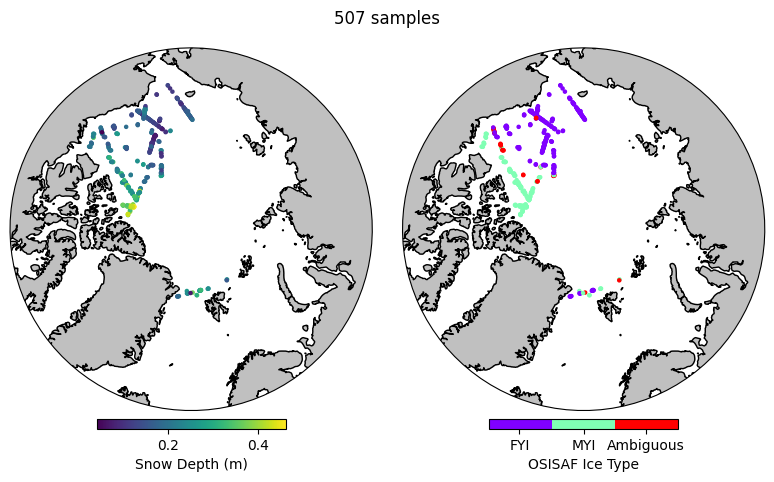

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(8, 5), subplot_kw={'projection': ccrs.NorthPolarStereo()})
for ax in axs:
    ax.set_extent([-180, 180, 65, 90], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAND, color='silver')
    set_axis_boundary_circular(ax)
snod_scatter = axs[0].scatter(unified_ds['xc_01'], unified_ds['yc_01'], c=unified_ds['mean_snow_depth_01'], s=5, transform=ccrs.epsg(6931))
plt.colorbar(snod_scatter, ax=axs[0], label='Snow Depth (m)', orientation='horizontal', pad=0.02, shrink=0.5)
ice_type_cmap = plt.get_cmap('rainbow', 3)
type_scatter = axs[1].scatter(unified_ds['xc_01'], unified_ds['yc_01'], c=unified_ds['sitype_osisaf_01'], s=5, transform=ccrs.epsg(6931), cmap=ice_type_cmap, vmin=2.5, vmax=3.5)
type_cbar = plt.colorbar(type_scatter, ax=axs[1], label='OSISAF Ice Type', orientation='horizontal', pad=0.02, shrink=0.5)
type_cbar.set_ticks([2.66, 3, 3.33])
type_cbar.set_ticklabels(['FYI', 'MYI', 'Ambiguous'])
num_samples = unified_ds['mean_snow_depth_01'].count().values
plt.suptitle(f'{num_samples} samples')
plt.tight_layout()
plt.show()
plt.show()

Let's visualise the relationship between our S3 features and the OIB snow depths (and each other)

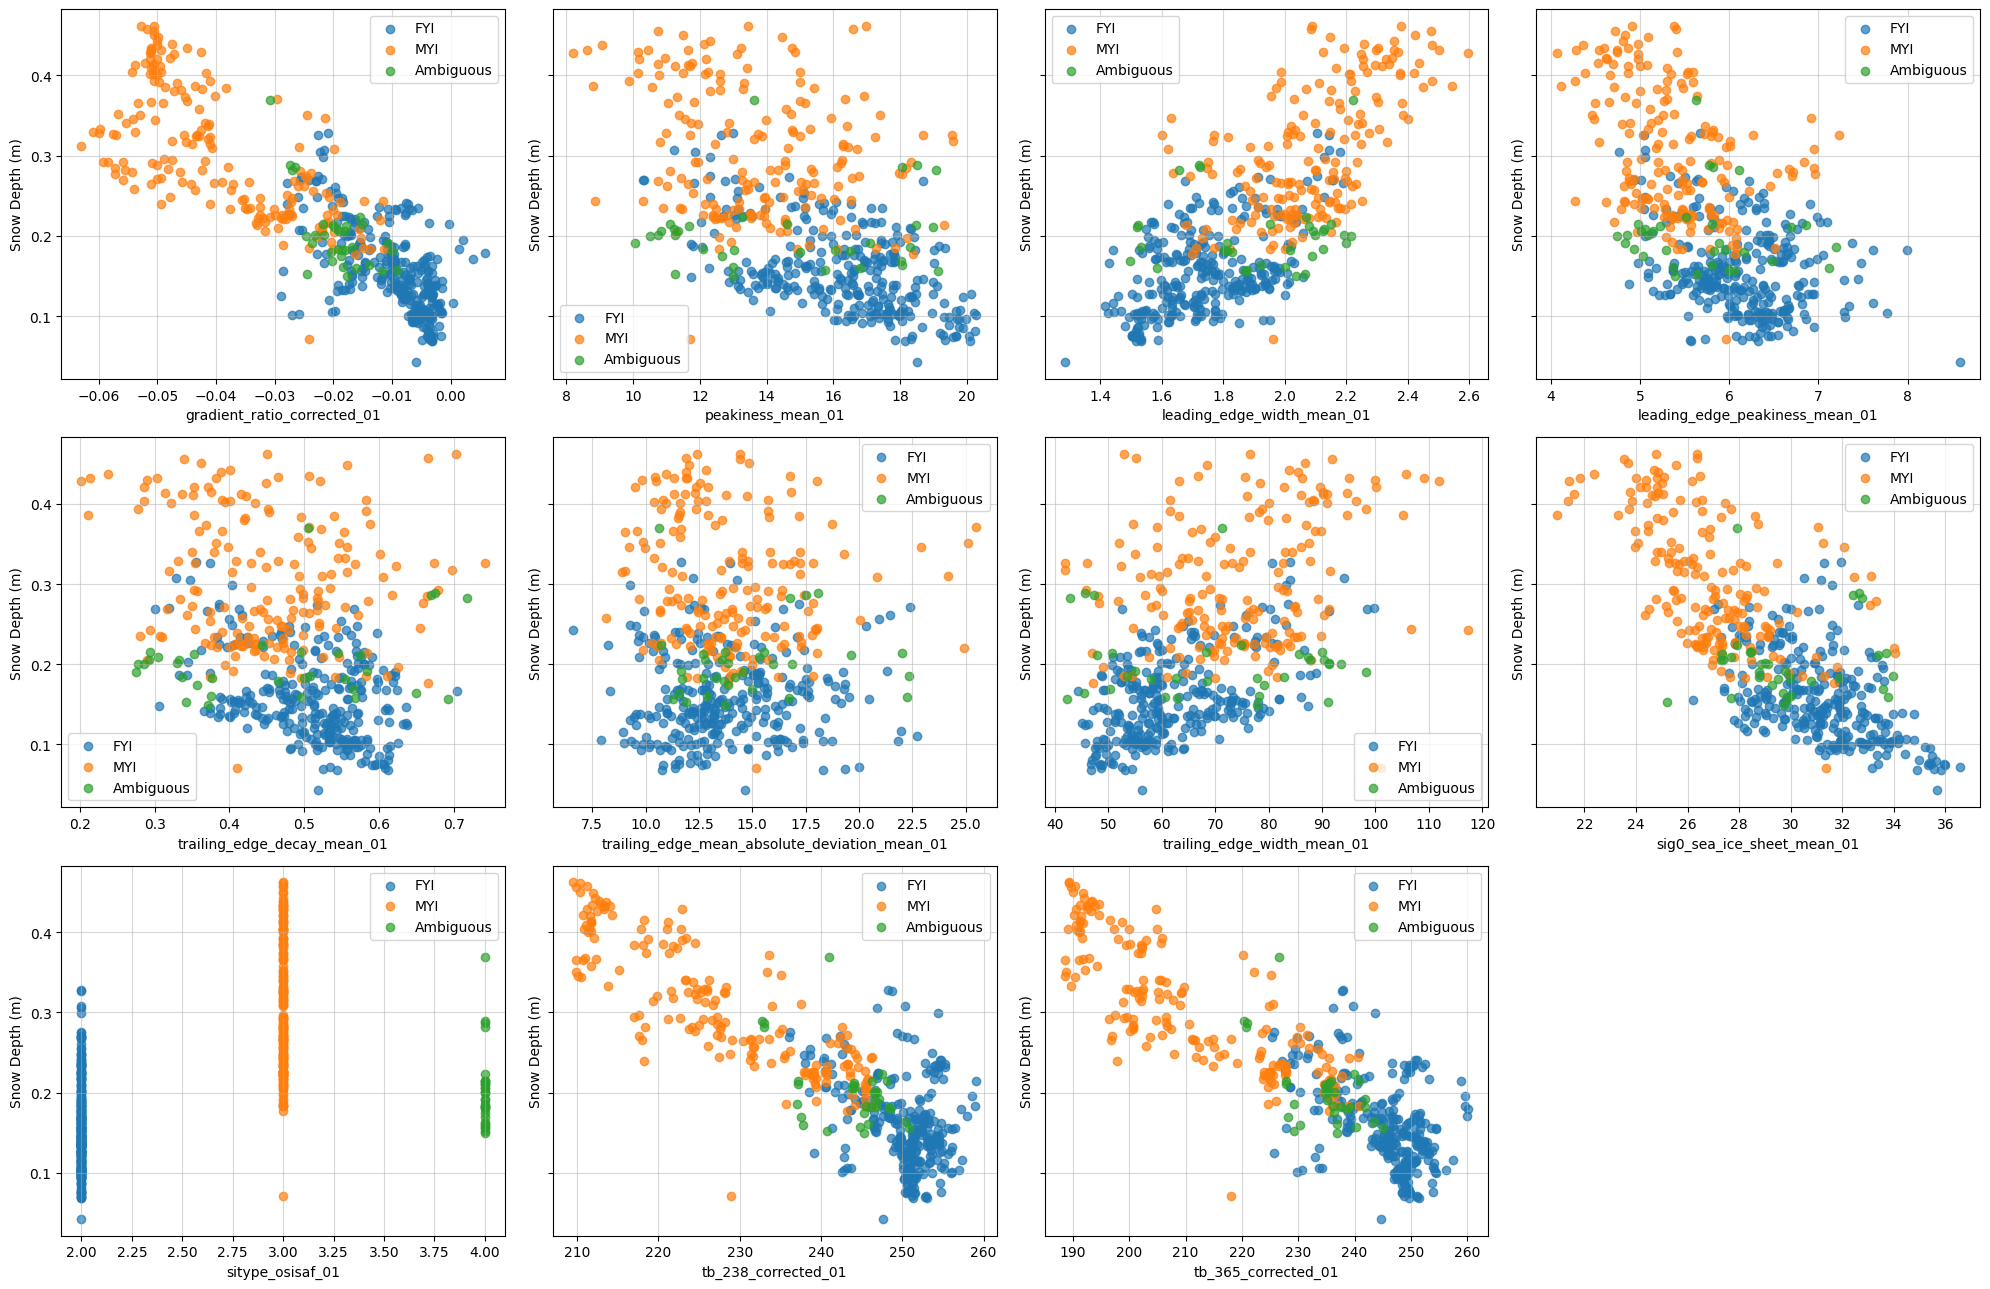

In [4]:
fig, axs = plt.subplots(3, 4, figsize=(20, 13), sharey=True)
for i, var in enumerate(feature_subset):
    ax = axs.flatten()[i]
    ax.grid(True, alpha=0.5)
    for ice_type, type_label in zip([2, 3, 4], ['FYI', 'MYI', 'Ambiguous']):
        subset = unified_ds.where(unified_ds.sitype_osisaf_01 == ice_type, drop=True)
        ax.scatter(subset[var], subset['mean_snow_depth_01'], label=type_label, alpha=0.7)
    ax.set_ylabel('Snow Depth (m)')
    ax.set_xlabel(var)
    ax.legend()
axs[-1,-1].set_visible(False)
plt.tight_layout()
plt.show()

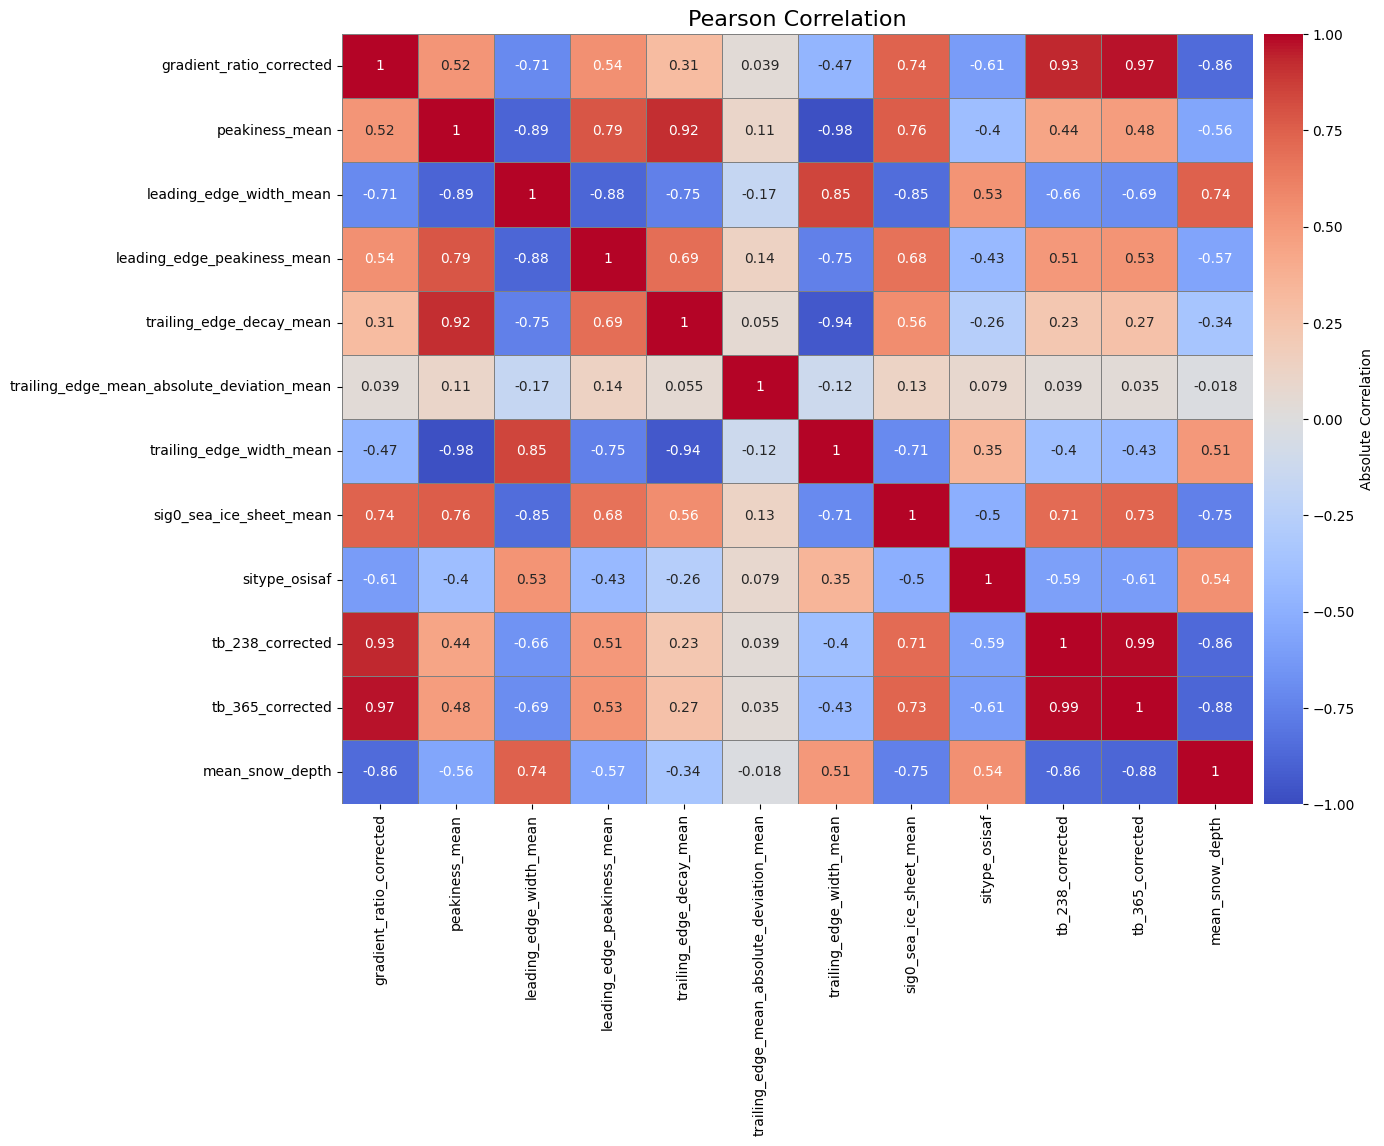

In [5]:
#heatmap of the correlation between the variables
fig, ax = plt.subplots(figsize=(14,10))
labels = [f'{var.replace(f"_01", "")}' for var in feature_subset+['mean_snow_depth_01']]
sns.heatmap(df[feature_subset+['mean_snow_depth_01']].corr(), annot=True, ax=ax, cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Absolute Correlation', 'pad': 0.01}, xticklabels=labels, yticklabels=labels)
plt.title('Pearson Correlation', fontsize=16)
plt.show()

## Part 2: Data Splitting

To evaluate our model, we must split the data into training and testing datasets. This allows us to assess how well our model generalizes to unseen data. Due to the limited number of sample (507) and to mitigate spatial autocorrelation, we will use blocked k-fold cross-validation. In this method, the data are first divided into FYI and MYI groups and then partitioned into spatial groups (blocks). These groups are then split into k folds such that all the data points from a single block remain together in either the training or testing setin each fold (mitigating inflated matrics from spatial autocorrelation). We only use random splits where the proportion of FYI to MYI is similar across the resulting folds such that they are relatively balanced. For this the nearest OSISAF sea ice type (OSI-403-d) classifiation is used and ambigious ice is grouped with FYI.

On each split, the model is trained on k-1 groups and tested on the remaining, unseen group. We will use the resulting metrics to compare different model hyperparameters and input feature combinaions, informing the final operational model configuration.

Let's define a class to support our data splitting procedure

In [ ]:
class GroupedBlockedKFold:

    def __init__(self, n_splits=5, spacing=150e3):
        """
        This class is essentially a wrapper around the BlockKFold class from the Verde library which allows for retrieval of balanced folds. 
        
        Parameters:
        n_splits (int): The number of folds to create.
        spacing (float): The grid cell spacing (m) to pass to Verde's BlockKFold, which determines the size of the blocks used for splitting the data.
        """
        self.n_splits = n_splits
        self.spacing = spacing
        self.group_fold_counts = []
        
    def set_generator(self, random_state=0):
        """
        Set the BlockKFold generator with a specified random state. 
        
        Parameters:
        random_state (int): The random state to use for shuffling the blocked data before splitting.
        """
        
        self.bkf = vd.BlockKFold(spacing=self.spacing, n_splits=self.n_splits, balance=True, shuffle=True, random_state=random_state)

    def split(self, coords, groups=None):
        
        """
        Split the data into folds based on the coordinates and group labels.
        For each group, the data is split into folds using the BlockKFold generator, and the train and test indices for each fold are stored in a dictionary. 
        The counts of samples in each fold for each group are also stored in a list of dictionaries.
        
        Parameters:
        coords (array-like): The coordinates of the samples, which will be used for blocking.
        groups (array-like): The group labels for the samples, which will be used for grouping. If None, all samples will be considered as belonging to the same group.
        
        """
        
        if not hasattr(self, 'bkf'):
            print('Generator not set. Setting generator with default random state of 0.')
            self.set_generator()
        
        if groups is None:
            groups = np.zeros(coords.shape[0], dtype=int)
        folds = {}
        for group in np.unique(groups):
            group_indices = np.where(groups == group)[0]
            group_fold_counts = []
            for i, (train, test) in enumerate(self.bkf.split(coords[group_indices])):
                if i not in folds:
                    folds[i] = (group_indices[train], group_indices[test])
                else:
                    folds[i] = (np.concatenate([folds[i][0], group_indices[train]]), np.concatenate([folds[i][1], group_indices[test]]))
                group_fold_counts.append({
                    'train_count': len(group_indices[train]),
                    'test_count': len(group_indices[test]),
                })
            self.group_fold_counts.append({
                'group': group,
                'folds': group_fold_counts
            })

        for fold in folds.values():
            yield fold
    
    def get_fold_counts(self):
        """
        Get the counts of samples in each fold for each group.
        """
        return self.group_fold_counts
    
    def get_df_test_train_indices(self, coords, groups):
        """
        Get the test and train indices for each fold. 
        
        Parameters:
        coords (array-like): The coordinates of the samples, which will be used for blocking.
        groups (array-like): The group labels for the samples, which will be used for grouping. If None, all samples will be considered as belonging to the same group.
        
        Returns:
        list of tuples: each tuple in the list contains the train and test indices for a fold.
        
        """
        train_test_indices = []
        for train, test in self.split(coords, groups):
            train_test_indices.append((train, test))
        return train_test_indices
    
    def get_balanced_random_states(self, coords, groups, max_fold_test_percentage_diff=5):
        """
        Get a list of random states that result in balanced folds.
        Being balanced is defined as a percentage difference between the number of test samples being less than or equal to the specified threshold across the folds. 
        
        Parameters:
        coords (array-like): The coordinates of the samples, which will be used for blocking.
        groups (array-like): The group labels for the samples, which will be used for grouping. If None, all samples will be considered as belonging to the same group.
        max_fold_test_percentage_diff (float): The maximum percentage difference between the percentage of test samples across the folds. Default is 5%.
        
        Returns:
        list: A list of random states that result in balanced folds.
        """
        
        random_states = np.arange(0, 200)
        balanced_random_states = []
        for random_state in random_states:
            self.set_generator(random_state)
            folds = self.get_df_test_train_indices(coords, groups)
            test_percentages = [len(test) / len(groups) for train, test in folds]
            test_percentage_diff = np.max(test_percentages) - np.min(test_percentages)
            if test_percentage_diff <= max_fold_test_percentage_diff/100:
                balanced_random_states.append(random_state)
        if len(balanced_random_states) == 0:
            print('No balanced random states found. Consider increasing the max_fold_test_percentage_diff threshold.')
        return balanced_random_states


Let's create a new ice type flag: 0 = FYI/Ambiguous and 1 = MYI

In [7]:
#add a new ice_type flag which is 1 if the ice type is MYI and 0 otherwise (FYI and ambiguous ice)
df['ice_type'] = 0
df.loc[df[f'sitype_osisaf_01'] == 3, 'ice_type'] = 1

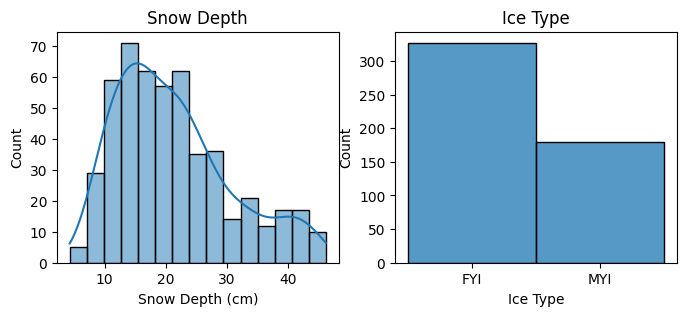

In [8]:
#let's look at the snow depth and updated ice type distribution fot the whole the dataset
fig, axs = plt.subplots(1, 2, figsize=(8, 3))
sns.histplot(df['mean_snow_depth_01']*100, kde=True, bins=15, ax=axs[0])
axs[0].set_title('Snow Depth')
axs[0].set_xlabel('Snow Depth (cm)')
sns.histplot(df['ice_type'], bins=[-0.5,0.5,1.5], ax=axs[1])
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['FYI', 'MYI'])
axs[1].set_title('Ice Type')
axs[1].set_xlabel('Ice Type')
plt.show()

Let's create our test-train splits that we'll be using to cross-validate the model

In [ ]:
df = df.reset_index(drop=True)
coords = df[['xc_01', 'yc_01']].values
ice_type = df['ice_type']

nsplits = 5 #we'll do 5 folds
spacing = 150e3 #150km block spacing

#initiate the BlockKFold generator and get the balanced random states for the specified parameters. 
groupedblock_generator = GroupedBlockedKFold(n_splits=nsplits, spacing=spacing)
balanced_random_states = groupedblock_generator.get_balanced_random_states(coords, ice_type, max_fold_test_percentage_diff=5)

#set the generator with a balanced random state and get the test train indices for each fold
random_state = balanced_random_states[1]
print(f'Random State: {random_state}')
groupedblock_generator.set_generator(random_state=random_state)
folds = groupedblock_generator.get_df_test_train_indices(coords, ice_type)

Random State: 12


Let's plot the folds to see the spatial distribution of the train/test point and also the distribution of snow depths in each fold

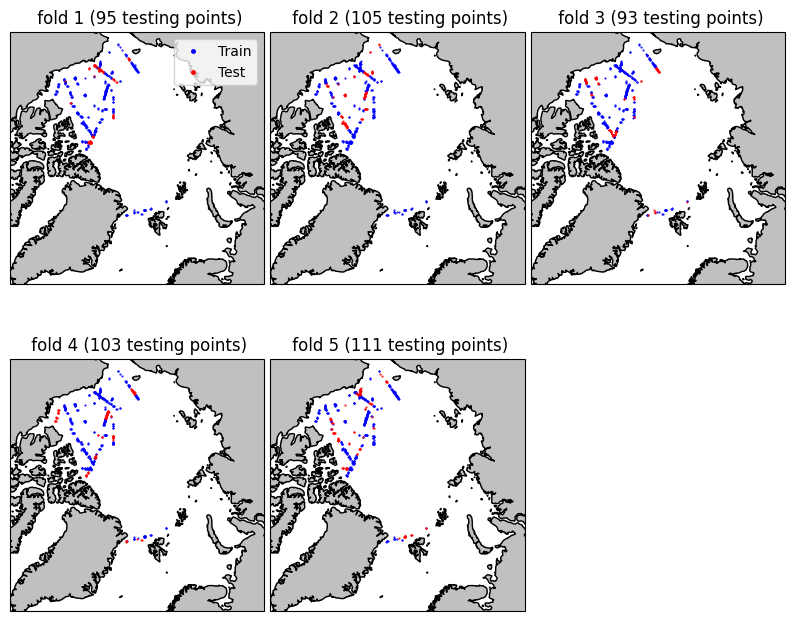

In [11]:
nfolds = len(folds)
nrows = int(np.ceil(nfolds/3))
fig, axs = plt.subplots(nrows,3, figsize=(10, 4.2*nrows), subplot_kw=dict(projection=ccrs.NorthPolarStereo()),sharex=True,sharey=True,)
for i, (ax, fold) in enumerate(zip(axs.ravel(), folds)):
    train, test = fold
    ax.set_title(" fold {} ({} testing points)".format(i+1, test.size))
    ax.add_feature(cfeature.LAND, color = 'silver')
    ax.add_feature(cfeature.COASTLINE)
    ax.set_extent([-180, 180, 68, 90], ccrs.PlateCarree())
    ax.plot(df[f'lon_01'].iloc[train].values, df[f'lat_01'].iloc[train].values,".b",markersize=1,transform=ccrs.PlateCarree(),label="Train")
    ax.plot(df[f'lon_01'].iloc[test].values, df[f'lat_01'].iloc[test].values,".r",markersize=1,transform=ccrs.PlateCarree(),label="Test") 
    if i == 0:
        ax.legend(loc="upper right", markerscale=5)
for ax in axs.ravel()[nfolds:]:
    ax.axis('off')
plt.subplots_adjust(hspace=0.02, wspace=0.025)
plt.show()

and look at the distribution of snow depths and ice types in each fold

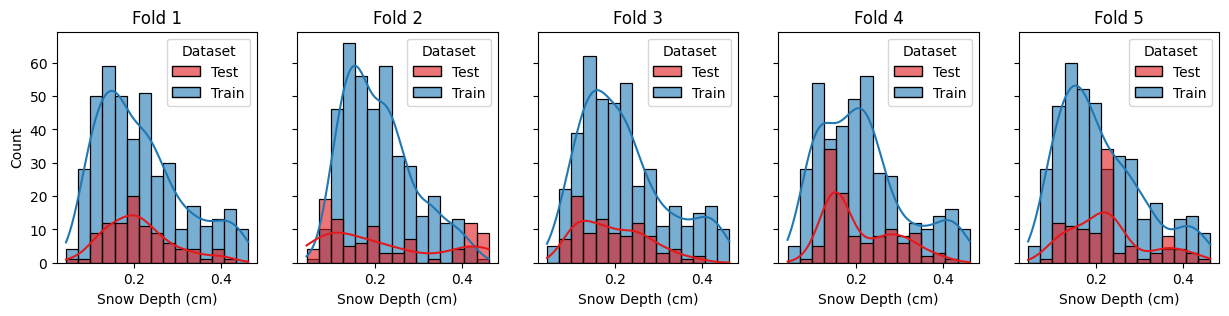

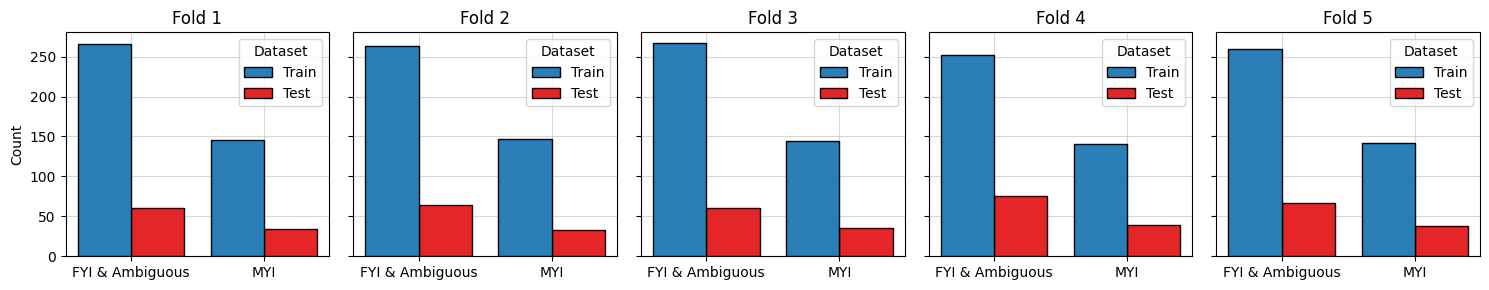

In [74]:
fig, axs = plt.subplots(1, nsplits , figsize=(15, 3), sharey=True)
bins = np.arange(0, 50, 5)
for i, fold in enumerate(folds):
    train, test = fold
    train_df = df.iloc[train].copy()
    train_df['Dataset'] = 'Train'
    test_df = df.iloc[test].copy()
    test_df['Dataset'] = 'Test'
    merged_df = pd.concat([train_df, test_df])
    merged_df['Dataset'] = merged_df['Dataset'].astype('category')
    palette = sns.color_palette(sns.color_palette("Paired"), n_colors=6)
    palette = [palette[5], palette[1]]
    sns.histplot(merged_df, x='mean_snow_depth_01', hue='Dataset', bins=15, kde=True, palette=palette, ax=axs[i],legend=True, alpha=0.6)
    axs[i].set_title(f'Fold {i+1}')
    axs[i].set_xlabel('Snow Depth (cm)')
plt.show()

fig, axs = plt.subplots(1, nsplits , figsize=(15, 3), sharey=True)
for i, fold in enumerate(folds):
    train, test = fold
    train_df = df.iloc[train].copy()
    train_df['Dataset'] = 'Train'
    test_df = df.iloc[test].copy()
    test_df['Dataset'] = 'Test'
    axs[i].grid(True, alpha=0.5,zorder=0)
    merged_df = pd.concat([train_df, test_df])
    palette = sns.color_palette(sns.color_palette("Paired"), n_colors=6)
    palette = [palette[1], palette[5]]
    sns.histplot(merged_df, x='ice_type', hue='Dataset', bins=[-0.5, 0.5, 1.5], multiple='dodge', shrink=0.8, palette=palette, ax=axs[i], alpha=0.95, zorder=50)
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['FYI & Ambiguous', 'MYI'])
    axs[i].set_title(f'Fold {i+1}')
    axs[i].set_xlabel('')
plt.tight_layout()
plt.show()


## Part 3.1: Ridge Regression - Hyperparameter and Feature Selection

Here, we will use our train and test folds to search for the optimal regression model hyperparameters and input features for snow depth prediction. We will use a Ridge regression model (see Hoerl and Kennard 1970 doi:10.2307/1267352 and doi:10.1080/00401706.1970.10488634) from the sklearn package (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html). This is a form of linear regression that applies a penalty to the regression coefficients that is proportional to the square of the magnitude of the regression coefficients, thereby shrinking them. The benefit of this is increased generalizability and stability, especially where there is noise in the training dataset and correlated input features. 

The size of the ridge penalty is controlled by the alpha parameter. We will seek to find an optimal alpha and set of input features by performing cross-validation repeatedly with different combinations and assessing the performance metrics. For feature selction, we will use the ExhaustiveFeaureSelection tool from the mlxtend package (https://rasbt.github.io/mlxtend/user_guide/feature_selection/ExhaustiveFeatureSelector/) which iterates through every possible combination of features.

In [ ]:

def make_ridge_pipeline(alpha=1.0, poly_degree=1, solver='auto'):
    """
    Make a sklearn pipeline for ridge regression with polynomial features and standard scaling.
    
    Parameters:
    alpha (float): Regularization strength for ridge regression. Default is 1.0.
    poly_degree (int): Degree of the polynomial features. Default is 1 (no polynomial features).
    solver (str): Solver to use for ridge regression. Default is 'auto'. If the input data is sparse, 'sparse_cg' will be used. If the input data is dense, 'cholesky' will be used.

    Returns:
    sklearn.pipeline.Pipeline: A pipeline object for ridge regression.
    """

    steps = []
    steps.append(('scaler', StandardScaler()))
    steps.append(('poly', PolynomialFeatures(degree=poly_degree)))
    steps.append(('ridge', Ridge(alpha=alpha, solver=solver)))
    return Pipeline(steps)

#=====================================================================================================================================================#

def get_best_nfeature_scorer_dfs(exhaustive_feature_score_df, r2=True, mae=True, rmse=True, plot_score_curves=True, ylims=[None, None, None]):
    """
    Get the best model for each number of features and each alpha value based on the specified scoring metrics. Optionally, plot the score curves for R², MAE, and RMSE as a function of the number of features for different alpha values.
    
    Parameters:
    exhaustive_feature_score_df (pd.DataFrame): A DataFrame containing the average scores and standard deviations for each combination of number of features and alpha value.
    r2 (bool): Whether to consider R² score when determining the best model. Default is True.
    mae (bool): Whether to consider MAE when determining the best model. Default is True.
    rmse (bool): Whether to consider RMSE when determining the best model. Default is True.
    plot_score_curves (bool): Whether to plot the score curves for R², MAE, and RMSE as a function of the number of features for different alpha values. Default is True.
    ylims (list): A list of y-axis limits for the R², MAE, and RMSE plots, respectively. Default is [None, None, None]. 
    
    Returns:
    tuple: A tuple containing the best R², MAE, and RMSE DataFrames, respectively. Each DataFrame contains the best model for each number of features and each alpha value based on the specified scoring metric. If a particular scoring metric is not considered, the corresponding DataFrame will be None.
    """
    
    best_r2 = exhaustive_feature_score_df.loc[exhaustive_feature_score_df.groupby(['n_features', 'alpha'])['r2_avg_score'].idxmax()] if r2 else None
    best_mae = exhaustive_feature_score_df.loc[exhaustive_feature_score_df.groupby(['n_features', 'alpha'])['neg_mean_absolute_error_avg_score'].idxmax()] if mae else None
    best_rmse = exhaustive_feature_score_df.loc[exhaustive_feature_score_df.groupby(['n_features', 'alpha'])['neg_root_mean_squared_error_avg_score'].idxmax()] if rmse else None
    
    alphas = exhaustive_feature_score_df['alpha'].unique()
    if plot_score_curves:
        plot_nfeature_score_curves(best_r2, best_mae, best_rmse, alphas, ylims=ylims)
    return best_r2, best_mae, best_rmse

#=====================================================================================================================================================#

def plot_nfeature_score_curves(best_r2, best_mae, best_rmse, alphas, ylims=[None, None, None]):
    """
    Plot the score curves for R², MAE, and RMSE as a function of the number of features for different alpha values.
    
    Parameters:
    best_r2 (pd.DataFrame): DataFrame containing the best R² scores for each number of features and alpha value.
    best_mae (pd.DataFrame): DataFrame containing the best MAE scores for each number of features and alpha value.
    best_rmse (pd.DataFrame): DataFrame containing the best RMSE scores for each number of features and alpha value.
    alphas (array-like): The unique alpha values to plot.
    ylims (list): A list of y-axis limits for the R², MAE, and RMSE plots, respectively. Default is [None, None, None].
    """

    palette = sns.color_palette('viridis', len(alphas))
    nsubplots = sum([best_r2 is not None, best_mae is not None, best_rmse is not None])
    fig, axs = plt.subplots(1, nsubplots, figsize=(8*nsubplots, 5))
    i = 0 
    scorer_labels = {'r2': 'R² Score', 'neg_mean_absolute_error': 'Negative MAE (m)', 'neg_root_mean_squared_error': 'Negative RMSE (m)'}
    for best_df, scorer in zip([best_r2, best_mae, best_rmse], ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']):
        if best_df is not None:
            axs[i].grid(True, alpha=0.5, zorder=0)
            for j, alpha in enumerate(alphas):
                alpha_df = best_df.loc[best_df['alpha'] == alpha]
                sns.lineplot(data=alpha_df, x='n_features', y=f'{scorer}_avg_score', ax=axs[i], color=palette[j], zorder=10, label = f'{alpha}', marker='o', markersize=5)
                axs[i].fill_between(alpha_df['n_features'], alpha_df[f'{scorer}_avg_score'] - alpha_df[f'{scorer}_cv_std'], alpha_df[f'{scorer}_avg_score'] + alpha_df[f'{scorer}_cv_std'], alpha=0.3, color=palette[j])
            axs[i].legend(title='Alpha', loc='lower right')
            # axs[i].set_title(scorer)
            axs[i].set_xlabel('Number of Features', fontsize=12)
            axs[i].set_ylabel(scorer_labels[scorer], fontsize=12)
            axs[i].set_ylim(ylims[i])
            i += 1
    plt.show()
    


In [17]:
#define the feature columns that we will consider for our model
feature_cols = [f'gradient_ratio_corrected_01', f'peakiness_mean_01', f'leading_edge_width_mean_01',
            f'leading_edge_peakiness_mean_01', f'trailing_edge_decay_mean_01',
            f'trailing_edge_width_mean_01', f'sig0_sea_ice_sheet_mean_01']
X = df[feature_cols]
max_features = X.shape[1]

#define the target variable
y = df[f'mean_snow_depth_01']

#define the alphas to test for ridge regression
alphas = [0.01, 0.1, 1.0, 10, 50, 100]

#let's iterate through the alphas and perform exhaustive feature selection for each alpha and each scorer, storing the results in a list of dataframes.
score_dfs = []
for alpha in alphas:
    print(f'Processing Alpha: {alpha}')
    
    pipeline = make_ridge_pipeline(alpha=alpha)
    alpha_scores = []
    for scorer in ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']: #set the metrics to evaluate
        efs = ExhaustiveFeatureSelector(
            pipeline,
            min_features=1,
            max_features=max_features,
            cv=folds,
            scoring=scorer,
            n_jobs=10,
            print_progress=False
        )
        efs = efs.fit(X, y)
        
        fselection_scores = pd.DataFrame.from_dict(efs.subsets_).T
        fselection_scores.rename(columns={
            'cv_scores': f'{scorer}_cv_score',
            'avg_score': f'{scorer}_avg_score'
        }, inplace=True)
        
        fselection_scores['alpha'] = alpha
        alpha_scores.append(fselection_scores)

    alpha_score_df = alpha_scores[0]
    for additional_scores in alpha_scores[1:]:
        alpha_score_df = pd.merge(alpha_score_df, additional_scores, on=['feature_names', 'feature_idx', 'alpha'])

    score_dfs.append(alpha_score_df)

#concatenate the score dataframes for each alpha into a single dataframe
final_score_df = pd.concat(score_dfs).reset_index(drop=True)
final_score_df['n_features'] = final_score_df['feature_names'].apply(lambda x: len(x))

#calculate std of the cv scores across the folds
for i, scorer in enumerate(['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']):
    final_score_df[f'{scorer}_avg_score'] = final_score_df[f'{scorer}_avg_score'].astype(float)
    final_score_df[f'{scorer}_cv_std'] = final_score_df[f'{scorer}_cv_score'].apply(lambda x: np.std(x))


Processing Alpha: 0.01
Processing Alpha: 0.1
Processing Alpha: 1.0
Processing Alpha: 10
Processing Alpha: 50
Processing Alpha: 100


Having done our exhaustive feature selector with cross-validation and varying alpha, let's look at how the alpha parameter and the number of features used to fit the model impacts results. Let's plot the best scoring combination of features for each alpha and number of features.

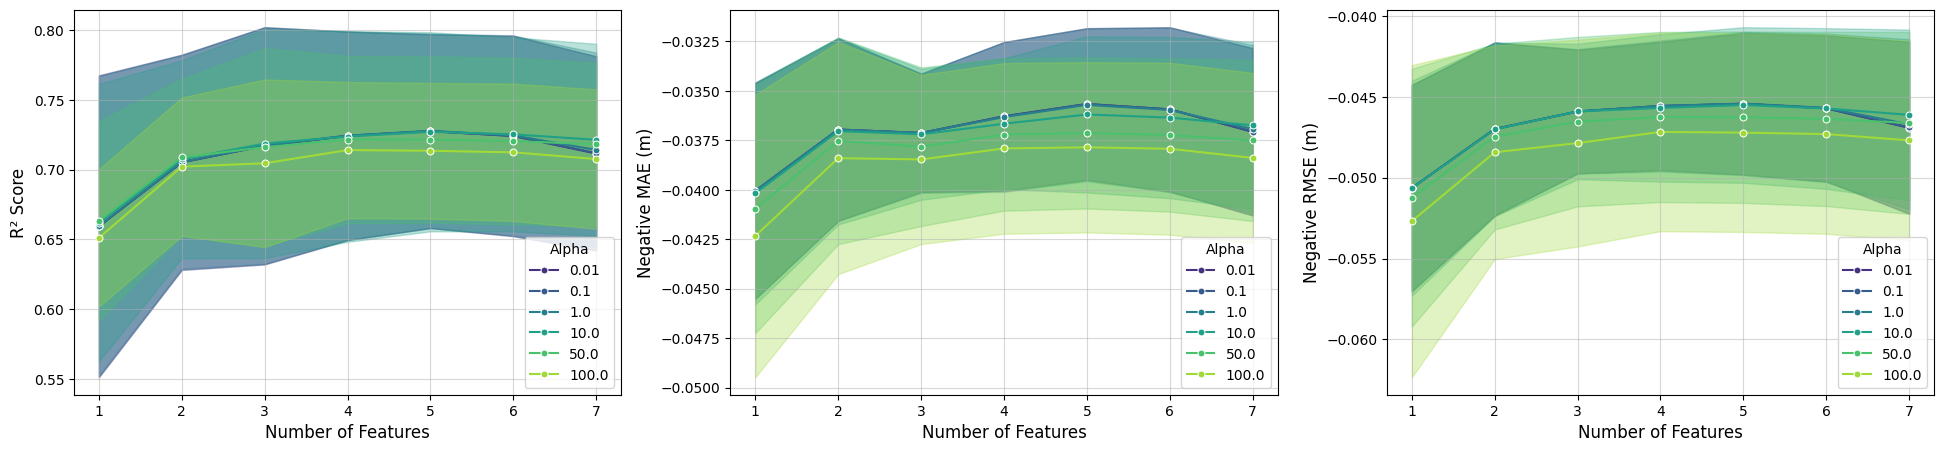

In [ ]:
best_r2, best_mae, best_rmse = get_best_nfeature_scorer_dfs(final_score_df, r2=True, mae=True, rmse=True, plot_score_curves=True)

The alphas between 0 and 10 seem to give the best scores, whereas 50-100 return clearly worse scores. Let's perform the cross-validation again using more alphas in the 0.1 - 20 range

In [20]:
X = df[feature_cols]
y = df[f'mean_snow_depth_01']

alphas = [0.1, 0.5, 1, 5, 10, 15, 20]
max_features = X.shape[1]

score_dfs = []
for alpha in alphas:
    print(f'Processing Alpha: {alpha}')
    pipeline = make_ridge_pipeline(alpha=alpha)
    alpha_scores = []
    
    for scorer in ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']:
        efs = ExhaustiveFeatureSelector(
            pipeline,
            min_features=1,
            max_features=max_features,
            cv=folds,
            scoring=scorer,
            n_jobs=10,
            print_progress=False
        )
        efs = efs.fit(X, y)
        
        fselection_scores = pd.DataFrame.from_dict(efs.subsets_).T
        fselection_scores.rename(columns={
            'cv_scores': f'{scorer}_cv_score',
            'avg_score': f'{scorer}_avg_score'
        }, inplace=True)
        
        fselection_scores['alpha'] = alpha
        alpha_scores.append(fselection_scores)

    alpha_score_df = alpha_scores[0]
    for additional_scores in alpha_scores[1:]:
        alpha_score_df = pd.merge(alpha_score_df, additional_scores, on=['feature_names', 'feature_idx', 'alpha'])

    score_dfs.append(alpha_score_df)

final_score_df = pd.concat(score_dfs).reset_index(drop=True)

final_score_df['n_features'] = final_score_df['feature_names'].apply(lambda x: len(x))

#calculate std of the cv scores
for i, scorer in enumerate(['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']):
    final_score_df[f'{scorer}_avg_score'] = final_score_df[f'{scorer}_avg_score'].astype(float)
    final_score_df[f'{scorer}_cv_std'] = final_score_df[f'{scorer}_cv_score'].apply(lambda x: np.std(x))


Processing Alpha: 0.1
Processing Alpha: 0.5
Processing Alpha: 1
Processing Alpha: 5
Processing Alpha: 10
Processing Alpha: 15
Processing Alpha: 20


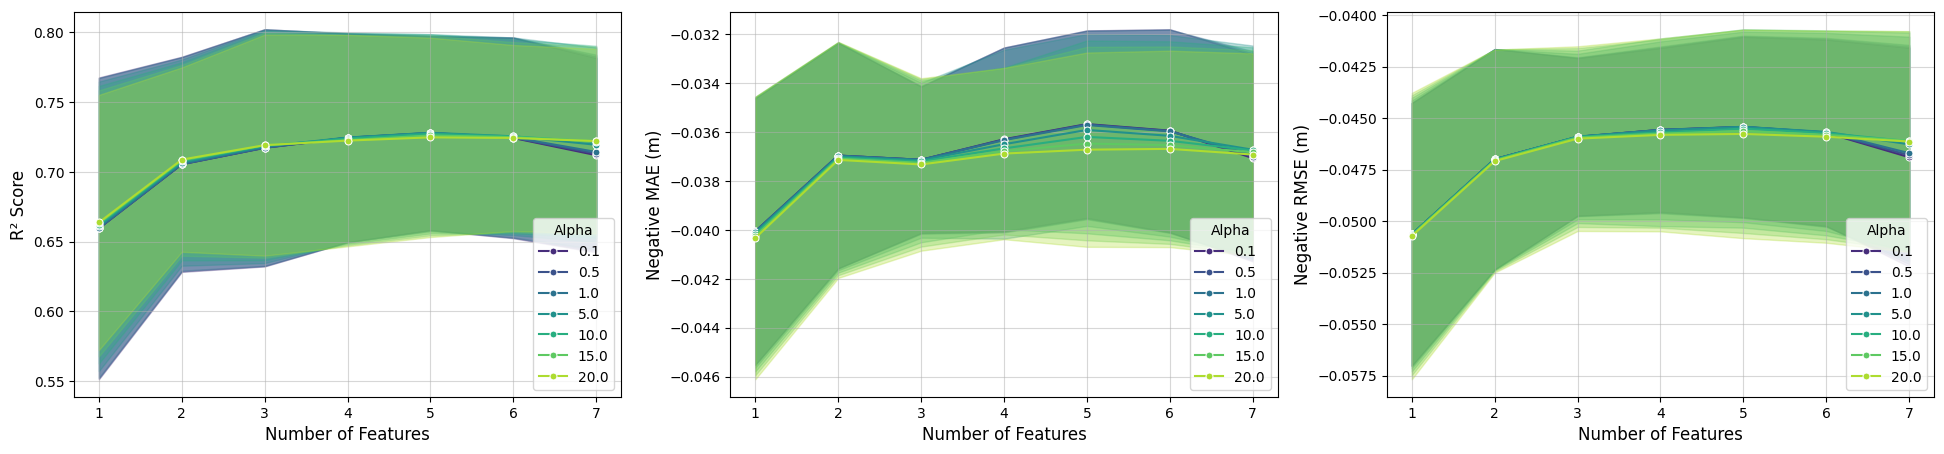

In [21]:
best_r2, best_mae, best_rmse = get_best_nfeature_scorer_dfs(final_score_df, r2=True, mae=True, rmse=True, plot_score_curves=True)

The alphas in this range appear to have relatively similar performance, particularly up to ~ 3 features. There also tends to be a plateau in performance and reduction in the standard deviation for the error metrics at ~ 3 features  We will select an alpha of 1 and determine the best feature combination of predictors when the performance plateaus by specifying some thresholds. Ideally, we want to stop adding features when the gain by adding more is less than the inreased risk of overfitting.

Let us first find the best combination of predictors for when the -RMSE gain is less than 5 mm for the two prior and one following addition of a feature.

In [ ]:
alpha = 1
min_rmse_increase = 0.005
best_rmse = best_rmse.loc[best_rmse['alpha'] == alpha].sort_values(by='n_features').reset_index(drop=True)
best_rmse['rmse_increase'] = best_rmse['neg_root_mean_squared_error_avg_score'].diff()
for i, row in best_rmse.iterrows():
    if i == 0:
        continue
    if best_rmse.loc[i, 'rmse_increase'] < min_rmse_increase and best_rmse.loc[i-1, 'rmse_increase'] < min_rmse_increase and best_rmse.loc[i+1, 'rmse_increase'] < min_rmse_increase:
        best_nfeatures = best_rmse.loc[i, 'n_features']
        break
print(f'Best number of features: {best_nfeatures}')
top_rmse = best_rmse.loc[best_rmse['n_features'] == best_nfeatures].reset_index(drop=True)
print(top_rmse.iloc[0]['feature_names'])
print(f'R2 Score: {top_rmse.iloc[0]["r2_avg_score"]}')
print(f'MAE Score: {top_rmse.iloc[0]["neg_mean_absolute_error_avg_score"]*-1}')
print(f'RMSE Score: {top_rmse.iloc[0]["neg_root_mean_squared_error_avg_score"]*-1}')
print(f'Alpha: {top_rmse.iloc[0]["alpha"]}')


Best number of features: 3
('gradient_ratio_corrected_01', 'leading_edge_width_mean_01', 'trailing_edge_decay_mean_01')
R2 Score: 0.7173256342063732
MAE Score: 0.037132700862109756
RMSE Score: 0.04590256902553717
Alpha: 1.0


Now, the best combination of predictors for when the -MAE gain is less than 5 mm for the two prior and one following addition of a feature.

In [37]:
alpha = 1
min_mae_increase = 0.005
best_mae = best_mae.loc[best_mae['alpha'] == alpha].sort_values(by='n_features').reset_index(drop=True)
best_mae['mae_increase'] = best_mae['neg_mean_absolute_error_avg_score'].diff()
for i, row in best_mae.iterrows():
    if i == 0:
        continue
    if best_mae.loc[i, 'mae_increase'] < min_mae_increase and best_mae.loc[i-1, 'mae_increase'] < min_mae_increase and best_mae.loc[i+1, 'mae_increase'] < min_mae_increase:
        best_nfeatures = best_mae.loc[i, 'n_features']
        break
print(f'Best number of features: {best_nfeatures}')
top_mae = best_mae.loc[best_mae['n_features'] == best_nfeatures].reset_index(drop=True)
print(top_mae.iloc[0]['feature_names'])
print(f'R2 Score: {top_mae.iloc[0]["r2_avg_score"]}')
print(f'MAE Score: {top_mae.iloc[0]["neg_mean_absolute_error_avg_score"]*-1}')
print(f'RMSE Score: {top_mae.iloc[0]["neg_root_mean_squared_error_avg_score"]*-1}')
print(f'Alpha: {top_mae.iloc[0]["alpha"]}')

Best number of features: 3
('gradient_ratio_corrected_01', 'leading_edge_width_mean_01', 'trailing_edge_decay_mean_01')
R2 Score: 0.7173256342063732
MAE Score: 0.037132700862109756
RMSE Score: 0.04590256902553717
Alpha: 1.0


Finally, the best combination of predictors for when the R² gain is less than 0.5 for the two prior and one following addition of a feature.

In [43]:
#Find the best performing models for our selected max features and alpha values
#The more features the model is fit on, the more sensitive it becomes to nosie in the data and to overfitting
#we therefore select the model the most features until the MAE increase is less than 5 mm for 2 consecutive features
alpha = 1
min_r2_increase = 0.01
best_r2 = best_r2.loc[best_r2['alpha'] == alpha].sort_values(by='n_features').reset_index(drop=True)
best_r2['r2_increase'] = best_r2['r2_avg_score'].diff()
for i, row in best_r2.iterrows():
    if i == 0:
        continue
    if best_r2.loc[i, 'r2_increase'] < min_r2_increase and best_r2.loc[i-1, 'r2_increase'] < min_r2_increase and best_r2.loc[i+1, 'r2_increase'] < min_r2_increase:
        best_nfeatures = best_r2.loc[i, 'n_features']
        break
print(f'Best number of features: {best_nfeatures}')
top_r2 = best_r2.loc[best_r2['n_features'] == best_nfeatures].reset_index(drop=True)
print(top_r2.iloc[0]['feature_names'])
print(f'R2 Score: {top_r2.iloc[0]["r2_avg_score"]}')
print(f'MAE Score: {top_r2.iloc[0]["neg_mean_absolute_error_avg_score"]*-1}')
print(f'RMSE Score: {top_r2.iloc[0]["neg_root_mean_squared_error_avg_score"]*-1}')
print(f'Alpha: {top_r2.iloc[0]["alpha"]}')

Best number of features: 5
('gradient_ratio_corrected_01', 'leading_edge_width_mean_01', 'leading_edge_peakiness_mean_01', 'trailing_edge_decay_mean_01', 'trailing_edge_width_mean_01')
R2 Score: 0.7277914742346695
MAE Score: 0.035709785332752444
RMSE Score: 0.04541818611982338
Alpha: 1.0


## Part 3.2: Ridge Regression - Optimal Model

For the three assessment metrics considered, GR, LEW, and TED, were consistently featured in the optimal set of features. For RMSE and MAE, the optimal combination was solely these three, whereas for R² leading edge peakiness and trailing edge width were also part of the optimal set. Based on these results, and a preference for fewer features to mitigate the risk of overfitting, the overall optimal model is decided to have an alpha of 1 and input features of GR, LEW and TED.

Let us now explore this combination in more detail.

In [ ]:
def calculate_prediction_metrics(y_true, y_pred):
    """
    Calculate various performance metrics for model predictions.
    
    Parameters:
    y_true (array-like): The true target values.
    y_pred (array-like): The predicted target values.
    
    Returns:
    tuple: A tuple containing the calculated metrics in the following order: RMSE, R² score, MAE, correlation coefficient (r), and bias.
    """
    
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r = np.corrcoef(y_true, y_pred.flatten())[0,1]
    bias = np.mean(y_pred.flatten() - y_true)
    return rmse, r2, mae, r, bias

#=====================================================================================================================================================#

def plot_kfold_predictions_vs_truth(fold_predictions):
    """
    Plots the predicted values against the target OIB values for each fold in a k-fold cross-validation setup.
    
    Parameters:
    fold_predictions (dict): A dictionary where each key is a fold number and each value is another dictionary containing the true target values ('y_test') and the predicted target values ('y_pred') for that fold.
    
    Returns:
    tuple: A tuple containing the figure and axes of the created plot.
    """
    
    nfolds = len(fold_predictions)
    nrows = int(np.ceil(nfolds/3))
    fig, axs = plt.subplots(nrows,3, figsize=(12, 4*nrows),sharex=True,sharey=True,)
    for i, ax in enumerate(axs.ravel()):
        if i >= nfolds:
            ax.axis('off')
            continue
        fold = i + 1
        y_test = fold_predictions[fold]['y_test']
        y_pred = fold_predictions[fold]['y_pred']
        ax = plot_prediction_vs_truth(ax, y_test, y_pred)
        ax.set_title(f'Fold {fold}')
    plt.tight_layout()
    return fig, axs

#=====================================================================================================================================================#

def plot_prediction_vs_truth(ax, y_true, y_pred):
    """
    Plots the predicted values against the target OIB values.
    
    Parameters:
    ax (matplotlib.axes.Axes): The axes on which to plot.
    y_true (array-like): The true target values.
    y_pred (array-like): The predicted target values.
    
    Returns:
    matplotlib.axes.Axes: The axes with the plot.
    """
    
    rmse, r2, mae, r, bias = calculate_prediction_metrics(y_true, y_pred)
    ax.grid(True, alpha=0.5)
    ax.scatter(y_true, y_pred, alpha=0.5)
    ax.plot([0, 0.5], [0, 0.5], color='black', linestyle='--')
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 0.5)
    ax.set_xlabel('OIB snow depth (m)')
    ax.set_ylabel('Predicted snow depth (m)')
    ax.text(0.055, 0.70, f'RMSE: {rmse:.2f}\nR$^2$: {r2:.2f}\nMAE: {mae:.2f}\nr: {r:.2f}\nBias: {bias:.2f}', transform=ax.transAxes)
    return ax


In [44]:
metric = 'neg_root_mean_squared_error_avg_score'
alpha = 1
top_feature_combination = list(top_rmse.iloc[0]['feature_names'])

X = df[top_feature_combination]

fold_predictions = {}
fold_results_df = pd.DataFrame({'Fold': range(1, nsplits + 1)})

for i, (train_idx, test_idx) in enumerate(folds):
    fold = i + 1
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

    pipeline = make_ridge_pipeline(alpha=alpha)

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    fold_predictions[fold] = {'y_test': y_test, 'y_pred': y_pred}
    
    fold_results_df.loc[fold_results_df['Fold'] == fold, ['RMSE', 'R2', 'MAE', 'r', 'Bias']] = calculate_prediction_metrics(y_test, y_pred)
    fold_results_df.loc[fold_results_df['Fold'] == fold, 'N_train'] = len(y_train)
    fold_results_df.loc[fold_results_df['Fold'] == fold, 'N_test'] = len(y_test)
    fold_results_df.loc[fold_results_df['Fold'] == fold, 'N_group_0_train'] = len(np.where(ice_type.iloc[train_idx] == 0)[0])
    fold_results_df.loc[fold_results_df['Fold'] == fold, 'N_group_0_test'] = len(np.where(ice_type.iloc[test_idx] == 0)[0])
    fold_results_df.loc[fold_results_df['Fold'] == fold, 'N_group_1_train'] = len(np.where(ice_type.iloc[train_idx] == 1)[0])
    fold_results_df.loc[fold_results_df['Fold'] == fold, 'N_group_1_test'] = len(np.where(ice_type.iloc[test_idx] == 1)[0])

In [46]:
print(fold_results_df)

   Fold      RMSE        R2       MAE         r      Bias  N_train  N_test  \
0     1  0.049853  0.844179  0.041296  0.938150 -0.015764    412.0    95.0   
1     2  0.039106  0.730639  0.032594  0.903140  0.021947    402.0   105.0   
2     3  0.046366  0.600429  0.039130  0.820452  0.011251    414.0    93.0   
3     4  0.049283  0.758732  0.037444  0.873374 -0.002426    404.0   103.0   
4     5  0.044906  0.652650  0.035198  0.848859 -0.013251    396.0   111.0   

   N_group_0_train  N_group_0_test  N_group_1_train  N_group_1_test  
0            268.0            59.0            144.0            36.0  
1            256.0            71.0            146.0            34.0  
2            265.0            62.0            149.0            31.0  
3            260.0            67.0            144.0            36.0  
4            259.0            68.0            137.0            43.0  


In [47]:
#print the mean R2, RMSE, MAE, r and bias
print('CV Results:')
print(f'Mean R2: {fold_results_df["R2"].mean()} ± {fold_results_df["R2"].std()}')
print(f'Mean RMSE: {fold_results_df["RMSE"].mean()} ± {fold_results_df["RMSE"].std()}')
print(f'Mean MAE: {fold_results_df["MAE"].mean()}  ± {fold_results_df["MAE"].std()}')
print(f'Mean r: {fold_results_df["r"].mean()} ± {fold_results_df["r"].std()}')
print(f'Mean Bias: {fold_results_df["Bias"].mean()} ± {fold_results_df["Bias"].std()}')

CV Results:
Mean R2: 0.7173256342063732 ± 0.09464574369313203
Mean RMSE: 0.04590256902553717 ± 0.004313934018427583
Mean MAE: 0.03713270086210975  ± 0.0033822953699844485
Mean r: 0.8767949860889633 ± 0.04589409052641879
Mean Bias: 0.0003511260902234442 ± 0.016105845289195526


Let's visualise our predictions against the target OIB snow depths for each fold

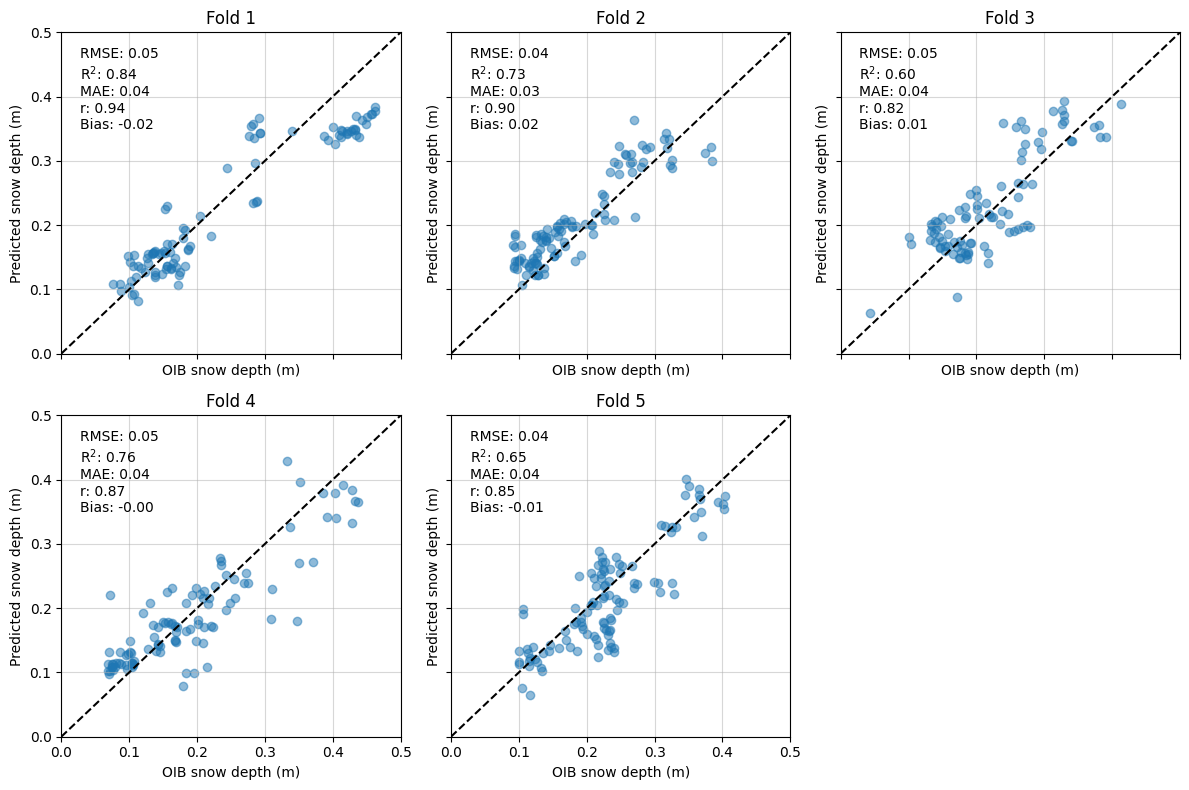

In [61]:
# plot the predictions vs true values for each fold
fig, axs = plot_kfold_predictions_vs_truth(fold_predictions)
plt.show()

To ensure our model is not under or over fitted, we can plot and expect the learning curves using the sklearn function (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html). This will iteratively train and score a model fitted on an increasing amount of the supplied training data within each fold. Convergence and plateauing between the training and testing scores signify the model is properly fitted.

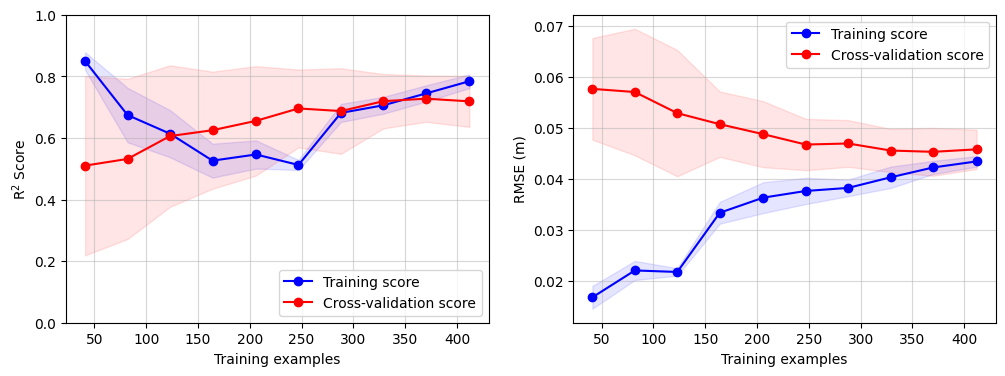

In [ ]:
pipeline = make_ridge_pipeline(alpha=alpha)

train_sizes, r2_train_scores, r2_test_scores = learning_curve(pipeline, X, y, cv=folds, n_jobs=10, train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2')
r2_train_scores_mean = np.mean(r2_train_scores, axis=1)
r2_train_scores_std = np.std(r2_train_scores, axis=1)
r2_test_scores_mean = np.mean(r2_test_scores, axis=1)
r2_test_scores_std = np.std(r2_test_scores, axis=1)

train_sizes, rmse_train_scores, rmse_test_scores = learning_curve(pipeline, X, y, cv=folds, n_jobs=10, train_sizes=np.linspace(0.1, 1.0, 10), scoring='neg_root_mean_squared_error')
rmse_train_scores_mean = np.mean(rmse_train_scores, axis=1) * -1
rmse_train_scores_std = np.std(rmse_train_scores, axis=1)
rmse_test_scores_mean = np.mean(rmse_test_scores, axis=1) * -1
rmse_test_scores_std = np.std(rmse_test_scores, axis=1)


fig, axs = plt.subplots(1,2, figsize=(12, 4))
axs[0].grid(True, alpha=0.5)
axs[0].fill_between(train_sizes, r2_train_scores_mean - r2_train_scores_std, r2_train_scores_mean + r2_train_scores_std, alpha=0.1, color="blue")
axs[0].fill_between(train_sizes, r2_test_scores_mean - r2_test_scores_std, r2_test_scores_mean + r2_test_scores_std, alpha=0.1, color="red")
axs[0].plot(train_sizes, r2_train_scores_mean, 'o-', color="blue", label="Training score")
axs[0].plot(train_sizes, r2_test_scores_mean, 'o-', color="red", label="Cross-validation score")
axs[0].set_xlabel("Training examples")
axs[0].set_ylabel(r"R$^2$ Score")
axs[0].legend(loc="lower right")
axs[1].grid(True, alpha=0.5)
axs[0].set_ylim(0, 1)
axs[1].fill_between(train_sizes, rmse_train_scores_mean - rmse_train_scores_std, rmse_train_scores_mean + rmse_train_scores_std, alpha=0.1, color="blue")
axs[1].fill_between(train_sizes, rmse_test_scores_mean - rmse_test_scores_std, rmse_test_scores_mean + rmse_test_scores_std, alpha=0.1, color="red")
axs[1].plot(train_sizes, rmse_train_scores_mean, 'o-', color="blue", label="Training score")
axs[1].plot(train_sizes, rmse_test_scores_mean, 'o-', color="red", label="Cross-validation score")
axs[1].set_xlabel("Training examples")
axs[1].set_ylabel("RMSE (m)")
axs[1].legend(loc="best")
plt.show()

An additional check for model robustness is repeating the cross-validation using different random seeds to split the initial data. We will therefore repeat the cross-validation for 10 different random states and visualise the aggregrate evaluation metrics.

Note that due to the random nature in choosing the 10 random states, this will produce a slightly different result each time it is run.

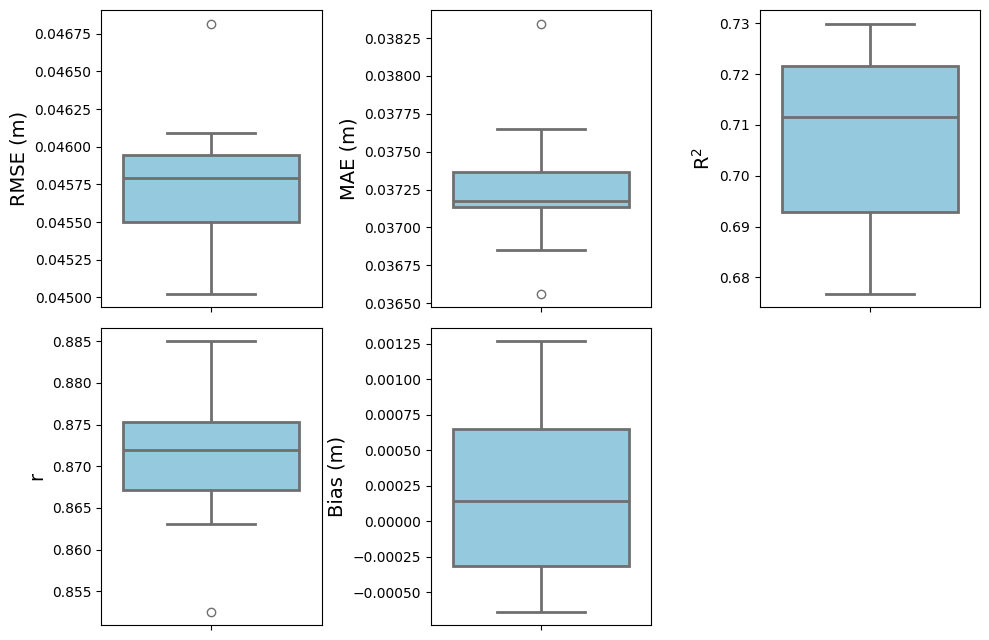

In [71]:
metrics_df = pd.DataFrame()

for k, random_state in enumerate(np.random.choice(balanced_random_states, 10, replace=False)):
    groupedblock_generator = GroupedBlockedKFold(n_splits=nsplits, spacing=spacing)
    groupedblock_generator.set_generator(random_state=random_state)
    folds = groupedblock_generator.get_df_test_train_indices(coords, ice_type)
    pipeline = make_ridge_pipeline(alpha=alpha)
    
    fold_predictions = {}
    for i, (train_idx, test_idx) in enumerate(folds):
        X_train, y_train = df.iloc[train_idx][top_feature_combination], df.iloc[train_idx]['mean_snow_depth_01']
        X_test, y_test = df.iloc[test_idx][top_feature_combination], df.iloc[test_idx]['mean_snow_depth_01']
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_pred = np.round(y_pred, 3)
        rmse, r2, mae, r, bias = calculate_prediction_metrics(y_test, y_pred)
        fold_predictions[i+1] = {
            'y_test': y_test,
            'y_pred': y_pred,
            'rmse': rmse,
            'r2': r2,
            'mae': mae,
            'r': r,
            'bias': bias
        }
        
    mean_rmse = np.mean([fold_predictions[i]['rmse'] for i in fold_predictions])
    mean_r2 = np.mean([fold_predictions[i]['r2'] for i in fold_predictions])
    mean_mae = np.mean([fold_predictions[i]['mae'] for i in fold_predictions])
    mean_r = np.mean([fold_predictions[i]['r'] for i in fold_predictions])
    mean_bias = np.mean([fold_predictions[i]['bias'] for i in fold_predictions])

    rmse_std = np.std([fold_predictions[i]['rmse'] for i in fold_predictions])
    r2_std = np.std([fold_predictions[i]['r2'] for i in fold_predictions])
    mae_std = np.std([fold_predictions[i]['mae'] for i in fold_predictions])
    r_std = np.std([fold_predictions[i]['r'] for i in fold_predictions])
    bias_std = np.std([fold_predictions[i]['bias'] for i in fold_predictions])

    metrics_df.loc[k, 'Random State'] = random_state
    for metric, mean in zip(['rmse', 'r2', 'mae', 'r', 'bias'], [mean_rmse, mean_r2, mean_mae, mean_r, mean_bias]):
        metrics_df.loc[k, metric] = mean

fig, axs = plt.subplots(2, 3, figsize=(10, 6.5))
axs = axs.flatten()
for i, (metric, label) in enumerate(zip(['rmse', 'mae','r2', 'r', 'bias'], ['RMSE (m)', 'MAE (m)', 'R$^2$','r', 'Bias (m)'])):
    sns.boxplot(data=metrics_df, y=metric, ax=axs[i], color='skyblue', linewidth=2)
    axs[i].set_ylabel(label, fontsize=14)
axs[-1].axis('off')
plt.tight_layout()
plt.show()


Let's apply our optimal model to the entire dataset and visualise the prediction of the training data.

 Note, we only report the cross-validation statistics when discussing the goodness of the model due to clear data leakage here. However, it is still interesting to see how the model fitted to the whole dataset does in predicting the OIB snow depths.

/tmp/ipykernel_2741497/3377306326.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', 2)


Text(0.78, 0.05, ' MYI\n N:180\n R$^2$: 0.60\n r: 0.77\n MAE: 0.04\n RMSE: 0.05\n Bias: -0.00')

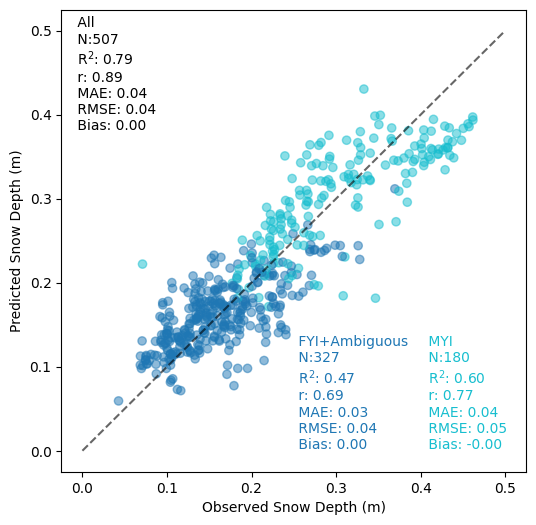

In [ ]:
#apply the model to the entire dataset
pipeline = make_ridge_pipeline(alpha=alpha)
X = df[top_feature_combination]
y = df[f'mean_snow_depth_01']
pipeline.fit(X, y)
y_pred = pipeline.predict(X)
rmse, r2, mae, r, bias = calculate_prediction_metrics(y, y_pred)

#predictions where ice type is FYI/ambiguous
X_fyi = df.loc[df['ice_type'] == 0, top_feature_combination]
y_pred_fyi = pipeline.predict(X_fyi)
y_pred_fyi = np.round(y_pred_fyi, 3)
rmse_fyi, r2_fyi, mae_fyi, r_fyi, bias_fyi = calculate_prediction_metrics(df.loc[df['ice_type'] == 0, 'mean_snow_depth_01'], y_pred_fyi)

#predictions where ice type is MYI
X_myi = df.loc[df['ice_type'] == 1, top_feature_combination]
y_pred_myi = pipeline.predict(X_myi)
y_pred_myi = np.round(y_pred_myi, 3)
rmse_myi, r2_myi, mae_myi, r_myi, bias_myi = calculate_prediction_metrics(df.loc[df['ice_type'] == 1, 'mean_snow_depth_01'], y_pred_myi)

#plot the results
cmap = plt.cm.get_cmap('tab10', 2)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(y, y_pred, c=df['ice_type'], cmap=cmap, alpha=0.5)
ax.plot([0,0.5], [0,0.5], 'k--', alpha=0.6)
ax.set_xlabel('Observed Snow Depth (m)')
ax.set_ylabel('Predicted Snow Depth (m)')
ax.text(0.025, 0.74, f' All\n N:{len(y_pred)}\n R$^2$: {r2:.2f}\n r: {r:.2f}\n MAE: {mae:.2f}\n RMSE: {rmse:.2f}\n Bias: {bias:.2f}', transform=ax.transAxes)
ax.text(0.5, 0.05, f' FYI+Ambiguous\n N:{len(y_pred_fyi)}\n R$^2$: {r2_fyi:.2f}\n r: {r_fyi:.2f}\n MAE: {mae_fyi:.2f}\n RMSE: {rmse_fyi:.2f}\n Bias: {bias_fyi:.2f}', transform=ax.transAxes,color=cmap(0))
ax.text(0.78, 0.05, f' MYI\n N:{len(y_pred_myi)}\n R$^2$: {r2_myi:.2f}\n r: {r_myi:.2f}\n MAE: {mae_myi:.2f}\n RMSE: {rmse_myi:.2f}\n Bias: {bias_myi:.2f}', transform=ax.transAxes,color=cmap(1))